<br>

## 1. Import Libraries

In [12]:
import pandas as pd
from sklearn.model_selection import train_test_split
from iterstrat.ml_stratifiers import MultilabelStratifiedKFold
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import f1_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



## 2. Load Modeling Data & Train-Test Split
Load the feature matrix (X) and target labels (y) prepared in previous steps.<br>
The dataset is then split into training and testing sets


In [2]:
# Load feature matrix and target labels
X=pd.read_pickle('../Data/processed_data/X_features.pkl')
y=pd.read_pickle('../Data/processed_data/y_target.pkl')

# combine for quick inspection
df=pd.concat([X, y], axis=1)
df.head()

,.NET,.NET Core,Angular,Angular.js,Ansible,Apache Spark,ASP.NET,ASP.NET Core,Assembly,Bash/Shell/PowerShell,...,front-end,full-stack,game or graphics,Marketing or sales professional,mobile,Product manager,QA or test,Scientist,Senior executive/VP,System administrator
0,1.724315,1.762893,-0.569413,-0.416451,-0.289751,-0.27559,2.257887,2.082232,-0.228229,-0.716789,...,0,1,0,0,0,0,0,0,0,0
1,-0.579940,-0.567249,-0.569413,-0.416451,-0.289751,-0.27559,-0.442892,-0.480254,-0.228229,-0.716789,...,0,1,0,0,1,0,0,0,0,0
2,-0.579940,-0.567249,-0.569413,-0.416451,-0.289751,-0.27559,-0.442892,-0.480254,-0.228229,-0.716789,...,1,0,0,0,1,0,0,0,0,0
3,-0.579940,-0.567249,-0.569413,-0.416451,3.451235,-0.27559,-0.442892,-0.480254,-0.228229,-0.716789,...,0,0,1,0,0,0,0,0,0,0
4,-0.579940,-0.567249,-0.569413,2.401240,-0.289751,-0.27559,-0.442892,-0.480254,-0.228229,-0.716789,...,0,1,0,0,0,0,0,0,0,0


In [3]:
# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

<br>

## 3. Hyperparameter Tuning

Optimize model hyperparameters using cross-validation to improve performance.

Perform Grid Search with multilabel stratified cross-validation to find the best hyperparameters based on **F1-micro** score.


The optimization objective is **F1-micro**, as it reflects overall performance across all labels.

In [ ]:
# Helper Function
def get_best_hyperparameters(clf, param_grid,X,y):
    cv = MultilabelStratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    grid_search = GridSearchCV(clf, param_grid, cv = cv, scoring='f1_micro',n_jobs=-1)
    grid_search.fit(X,y)
    best_params = grid_search.best_params_
    return best_params


In [ ]:
# Initialize models with base configurations
LR_clf = OneVsRestClassifier(LogisticRegression(max_iter=1500,tol=1e-4))
SVC_clf = OneVsRestClassifier(LinearSVC(max_iter=1000,tol=1e-3))
RF_clf = RandomForestClassifier()

<br>

### &emsp; 3.1 Logistic Regression

In [6]:
LRparam_grid = {
    'estimator__C': [0.01, 0.1, 1, 10, 100],
    'estimator__penalty': ['l1', 'l2'],
    'estimator__solver': ['liblinear', 'saga']
}

LR_best_params=get_best_hyperparameters(LR_clf,LRparam_grid,X_train,y_train)
LR_best_params

{'estimator__C': 1,
 'estimator__penalty': 'l2',
 'estimator__solver': 'liblinear'}

<br>

### &emsp; 3.2 Support Vector Classifier

In [7]:
SVCparam_grid = {
    'estimator__C': [0.1, 1, 10, 100],
    'estimator__loss': ['hinge', 'squared_hinge'],
}

SVC_best_params=get_best_hyperparameters(SVC_clf,SVCparam_grid,X_train,y_train)
SVC_best_params

c:\Users\Yousef Amer\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\svm\_base.py:1225: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\Yousef Amer\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\svm\_base.py:1225: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\Yousef Amer\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\svm\_base.py:1225: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\Yousef Amer\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\svm\_base.py:1225: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\Yousef Amer\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\svm\_base.py:1225: ConvergenceWarning: Liblinear failed to converge, increase the

{'estimator__C': 1, 'estimator__loss': 'squared_hinge'}

<br>

### &emsp; 3.3 Random Forest

In [8]:
RFparam_grid =  {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2]
}

RF_best_params=get_best_hyperparameters(RF_clf,RFparam_grid,X_train,y_train)

RF_best_params

c:\Users\Yousef Amer\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\model_selection\_validation.py:378: FitFailedWarning: 
17 fits failed out of a total of 360.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\Yousef Amer\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\model_selection\_validation.py", line 686, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\Yousef Amer\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\ensemble\_forest.py", line 476, in fit
    trees = Parallel(
  File "c:\Users\Yousef Amer\AppData\Local\Programs\Python\Python310\lib\site-pack

{'max_depth': 30,
 'min_samples_leaf': 1,
 'min_samples_split': 5,
 'n_estimators': 200}

<br>

## 4. Model Evaluation

Evaluate the performance of the tuned models on the test set.

We use:
- F1-micro: measures overall performance across all labels
- F1-macro: evaluates performance equally across all labels (sensitive to imbalance)

<br>

### &emsp; 4.1 Apply Tuned Hyperparameters

In [9]:
# Apply the best hyperparameters obtained from GridSearchCV
LR_clf.set_params(**LR_best_params)
SVC_clf.set_params(**SVC_best_params)
RF_clf.set_params(**RF_best_params)

RandomForestClassifier(max_depth=30, min_samples_split=5, n_estimators=200)

<br>

### &emsp; 4.2 Define Models for Evaluation

In [10]:
# Store models in a dictionary for easy iteration
models_dict={
    'Logistic Regression' : LR_clf,
    'Support Vector Classifier' : SVC_clf,
    'Random Forest' : RF_clf
}

<br>

### &emsp; 4.3 Evaluate Models on Test Set

In [11]:
# Train each model and evaluate on test data

result=[]
for model_name,model in models_dict.items():

    # Train model & Predict on test set
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Compute evaluation metrics
    f1_micro = f1_score(y_test, y_pred, average='micro')
    f1_macro = f1_score(y_test, y_pred, average='macro')

    # Store results
    result.append({
        'model':model_name,
        'f1_micro':f1_micro,
        'f1_macro':f1_macro
        })


# Convert results to DataFrame
results_df = pd.DataFrame(result)

# Sort by performance
results_df = results_df.sort_values(by='f1_micro', ascending=False)

results_df

c:\Users\Yousef Amer\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\svm\_base.py:1225: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\Yousef Amer\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\svm\_base.py:1225: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\Yousef Amer\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\svm\_base.py:1225: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\Yousef Amer\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\svm\_base.py:1225: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\Yousef Amer\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\svm\_base.py:1225: ConvergenceWarning: Liblinear failed to converge, increase the

,model,f1_micro,f1_macro
0,Logistic Regression,0.509890,0.201074
2,Random Forest,0.501504,0.151533
1,Support Vector Classifier,0.496804,0.148581


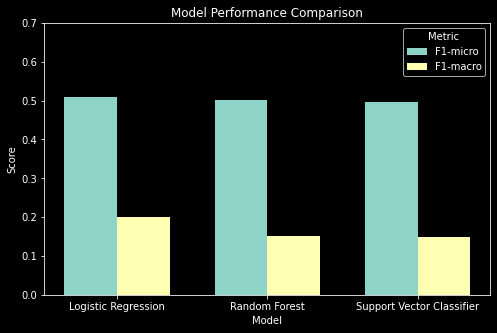

In [70]:
# Visualize model performance to compare models using F1-micro and F1-macro scores

plt.figure(figsize=(8, 5))

x = np.arange(len(results_df['model']))

# Bar width
width = 0.35

# Plot bars side by side
plt.bar(x - width/2, results_df['f1_micro'], width, label='F1-micro')
plt.bar(x + width/2, results_df['f1_macro'], width, label='F1-macro')

# Labels and title
plt.title('Model Performance Comparison')
plt.xlabel('Model')
plt.ylabel('Score')

plt.xticks(x, results_df['model'], rotation=0)

plt.ylim(0, 0.7)

plt.legend(title="Metric")

### Observation

- **Logistic Regression** achieved the best overall performance:
  - Highest F1-micro (~0.51)
  - Highest F1-macro (~0.20)

- **Random Forest** and **SVC** showed slightly lower performance, with very similar scores:
  - F1-micro around ~0.50
  - F1-macro significantly lower (~0.15)

- A noticeable gap exists between **F1-micro** and **F1-macro** across all models.

<br>

### Conclusion

- **Logistic Regression** is selected as the best-performing model.

- The relatively high **F1-micro** indicates that models perform reasonably well on frequent labels.

- The low **F1-macro** suggests poor performance on rare labels, highlighting the impact of label imbalance.

- Linear models (Logistic Regression, SVC) achieve better performance than the tree-based model (Random Forest), which aligns with the nature of the dataset (high-dimensional and sparse).

<br>

### Next Step

Although Logistic Regression performs best, the low F1-macro indicates that the model struggles with less frequent labels.

To address this, we will apply **threshold tuning per label** in the next step.  <br>

This will allow the model to make more flexible decisions for each label, improving performance especially on less frequent labels.

<br>

## 5. Threshold Tuning 

Apply **per-label threshold tuning** instead of using a fixed threshold (0.5).

This allows the model to:
- Adjust decision threshold for each label
- Improve performance on less frequent labels
- Optimize predictions at the label level using F1-score

<br>


### &emsp;  5.1 Tune optimal thresholds for each label

In [72]:
# Tune optimal classification thresholds for each label by maximizing F1-score on training data

# Convert y_train to idxPy for faster indexing
y_train_array = y_train.to_numpy()

# Define candidate thresholds
threshold_values = np.arange(0.1, 1,0.05)

# Get predicted probabilities
y_probs = LR_clf.predict_proba(X_train)

# Store best thresholds per label
best_thrs=[]

# Loop over each label (column)
for label_idx in range(len(y_train_array[0])):
    best_score = 0
    best_thr=0.1

    # Try different thresholds
    for threshold in threshold_values:
        y_thr = (y_probs>threshold)
        score = f1_score(y_train_array[:, label_idx], y_thr[:, label_idx])
        if score > best_score:
            best_score = score
            best_thr = threshold
    best_thrs.append({
        'label_index':label_idx,
        'best_threshold':round(best_thr,2),
        'best_score': round(best_score,3)
        
    })

# Convert to DataFrame for inspection
best_thrs_df = pd.DataFrame(best_thrs)

best_thrs_df

,label_index,best_threshold,best_score
0,0,0.15,0.311
1,1,0.35,0.716
2,2,0.20,0.400
3,3,0.25,0.587
4,4,0.15,0.276
5,5,0.15,0.250
6,6,0.20,0.469
7,7,0.20,0.408
8,8,0.10,0.091
9,9,0.20,0.395


<br>


### &emsp; 5.2 Evaluate Model After Threshold Tuning
Apply the tuned thresholds to the test set and evaluate the updated model performance.

In [ ]:
# Get predicted probabilities on test set
y_test_probs = LR_clf.predict_proba(X_test)

# Extract best thresholds as a NumPy array
threshold_array = best_thrs_df['best_threshold'].values

# Apply thresholds using broadcasting
y_pred = (y_test_probs > threshold_array).astype(int)

# Evaluation after threshold tuning 
f1_micro_after = f1_score(y_test, y_pred, average='micro')
f1_macro_after = f1_score(y_test, y_pred, average='macro')

f1_micro_after , f1_macro_after

(0.5481746412526715, 0.33394096002594653)

The results show a noticeable improvement in both metrics after applying threshold tuning.

In the next step, we will compare the performance before and after tuning to quantify this improvement.

<br>


### &emsp; 5.3 Performance Comparison (Before vs After)
Compare model performance before and after threshold tuning to quantify the improvement.

In [130]:
# Extract Logistic Regression performance before threshold tuning
lr_results = results_df[results_df['model'] == 'Logistic Regression']

f1_micro_before = lr_results['f1_micro'].values[0]
f1_macro_before = lr_results['f1_macro'].values[0]

# Compute improvement percentages 
improvement_micro  = ((f1_micro_after / f1_micro_before) -1) * 100
improvement_macro  = ((f1_macro_after / f1_macro_before) -1) * 100


# Create comparison DataFrame
comparison_dict = {
    'Matric':['F1-micro', 'F1-macro'],
    'Before': [f1_micro_before, f1_macro_before],
    'after': [f1_micro_after, f1_macro_after],
    'Improvement_percentage':[improvement_micro, improvement_macro]
}
comparison_df = pd.DataFrame(comparison_dict)
comparison_df

,Matric,Before,after,Improvement_percentage
0,F1-micro,0.509890,0.548175,7.508359
1,F1-macro,0.201074,0.333941,66.078925


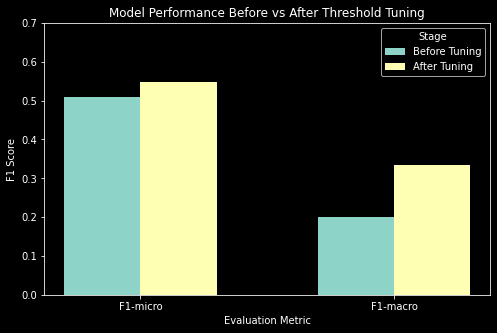

In [ ]:
# Plot a grouped bar chart to compare model performance before and after threshold tuning

plt.figure(figsize=(8, 5))

x = np.arange(len(comparison_df['Matric']))

# Bar width
width = 0.3

# Plot bars side by side
plt.bar(x - width/2, comparison_df['Before'], width, label='Before Tuning')
plt.bar(x + width/2, comparison_df['after'], width, label='After Tuning')

# Labels and title
plt.title('Model Performance Before vs After Threshold Tuning')
plt.xlabel('Evaluation Metric')
plt.ylabel('F1 Score')

plt.xticks(x, comparison_df['Matric'], rotation=0)

plt.ylim(0, 0.7)

plt.legend(title="Stage")

### Observation 

Threshold tuning significantly improved model performance across both evaluation metrics.

- **F1-micro** increased from 0.51 to 0.55 (**7.5% improvement**), showing a better overall performance across all labels.
- **F1-macro** increased from 0.20 to 0.33 (**66% improvement**), showing a strong gain in performance for less frequent labels.


---

### Key Insight

The large improvement in **F1-macro (66%)** confirms that threshold tuning effectively addresses label imbalance by allowing label-specific decision boundaries.

In contrast, the smaller improvement in **F1-micro (7.5%)** indicates that the model was already performing reasonably well on frequent labels, and most gains came from improving rare labels.

---

### Final Conclusion

Threshold tuning is a highly impactful optimization step in this multi-label classification problem.<br>  
It significantly improves fairness across labels, especially for minority labels.<br> 

As a result, the **Tuned Logistic Regression** model is the final selected model for this multi-label classification task.<br> 